ANALYSE DE L ENONCE

La formule donnée du PnL sur Wiki est: PnL = (Research × Scale × Speed) − Budget_Used

Plus précisément:

Soit $x,y,z \in [0,100]$ les pourcentages d'investisment respectivement en Research, Scale et Speed ( Evidemment $x+y+z\leq 100$), on a:

$PnL = 200000\frac{\ln(1+x)}{\ln(1+100)}\cdot 7\frac{y}{100}\cdot f(z)-50000\frac{x+y+z}{100}$

Donc
$\boxed{PnL(x,y,z) = 14 000\frac{\ln(1+x)}{\ln(101)}\cdot y\cdot f(z)-500(x+y+z)}$ 

f étant une fonction à valeur dans $[0.1,0.9]$

Une fois F bien approximée, on pourra trouver aisément les valeurs x,y,z maximisant le PnL par grid search ou analytiqument

En se disant que les autres ont déjà fait leur choix de z, 

$F(z)=0.8\cdot( \text{proportion de personnes ayant mis un pourcentage inférieur à z} )+0.1$

En notant $Z$ la variable aléatoire à valeur dans $[0,100] donnant le pourcentage en Speed choisi par une équipe, on a:

$\boxed{f(z)=0.8\cdot F_Z(z)+0.1}$

où $F_Z$ est la fonction de répartition de $Z$


Donc en actualisant notre formule, on a:

$\boxed{PnL(x,y,z) = 1 400\frac{\ln(1+x)}{\ln(101)}\cdot y\cdot(8F_Z(z)+1)-500(x+y+z)}$ 

On peut choisir de se demander quelle fonction croissante $F_Z:[0,100]\rightarrow [0,1]$ modélise le mieux le choix des gens (question purement probabiliste) et puis incorporer des idées de théorie des jeux ! 

In [73]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt
from scipy.stats import norm

In [74]:
def pnl_calculate(x, y, z, cdf, log_base):
    # On passe log_base en argument pour ne pas le recalculer
    return 1400 * np.log(1 + x) / log_base * y * (8 * cdf(z) + 1) - 500 * (x + y + z)

import numpy as np

def grid_search(cdf):
    max_val = 0
    best_coords = (0, 0, 0)
    
    log_101 = np.log(101)
    

    cdf_lookup = [8 * cdf(z) + 1 for z in range(101)]

    combos = ((x, y, z) for x in range(101) 
              for y in range(101 - x) 
              for z in range(101 - x - y))

    for x, y, z in combos:
        term1 = 1400 * (np.log(1 + x) / log_101)
        term2 = y * cdf_lookup[z]
        cost = 500 * (x + y + z)
        
        current_pnl = (term1 * term2) - cost
        
        if current_pnl > max_val:
            max_val = current_pnl
            best_coords = (x, y, z)
            
    return max_val, best_coords


Déjà on peut faire l'hypothèse que $Z\sim \mathcal{U}([0,100])$:

In [75]:
def uniform_cdf(z):
    return 0.01*z

print(grid_search(uniform_cdf))

(np.float64(110065.31395662151), (16, 48, 36))


In [76]:
#Check

x,y,z = 16,48,36
print(200000*np.log(1+16)/np.log(101)*7*48/100*(0.8*36/100+0.1)-50000*(16+48+36)/100)

110065.31395662154


PREMIER RESULTAT: $(x,y,z)=(16,48,36)$

Voyons si $Z$ suit plutôt une loi centrée autour du pourcentage p: 

In [77]:
#Triangle dont le sommet et à p et d'aire 1 modélisant une fonction densité
#hauteur du triangle: 0.02               /\
#                                       /  \
#                                      /    \
#                                     /      \
#                                    0    p  100

def centered_p_density(x,p):
    return 0.02*x/p if x<=p else 0.02*(100-x)/(100-p)
def centered_p_cdf(x,p):
    return x**2/(100*p) if x<=p else 1-(100-x)**2/(100*(100-p))

def centered_p_density_function(p):
    return lambda x: centered_p_density(x,p)
def centered_p_cdf_function(p):
    return lambda x :centered_p_cdf(x,p)


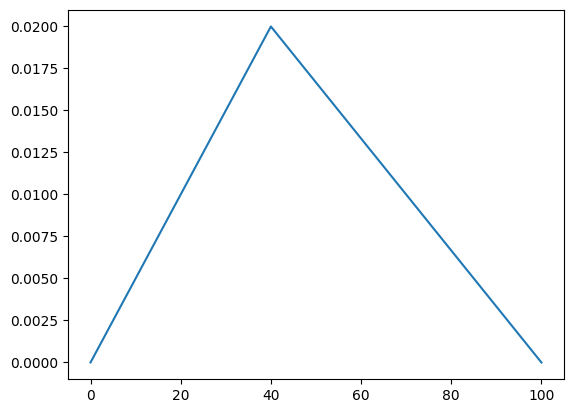

In [78]:
plt.plot([x for x in range(101)],[centered_p_density_function(40)(x) for x in range(101)])
plt.show()

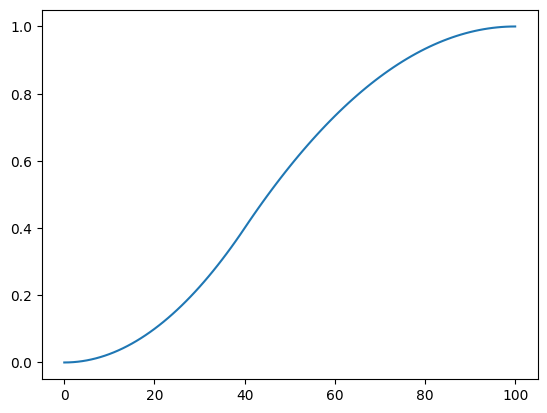

In [79]:
plt.plot([x for x in range(101)],[centered_p_cdf_function(40)(x) for x in range(101)])
plt.show()

Maintenant qu'on a notre fonction de répartition centrée en p on peut choisir p et observer:

In [80]:
print(grid_search(centered_p_cdf_function(50)))

(np.float64(98884.9215958995), (13, 35, 52))


DEUXIEME RESULTAT: $(x,y,z) = (13,35,52)$

Donc en supposant que les autres vont prendre un pourcentage centré en 50, on observe avec la densité linéaire piquée en 50 que comme pour la réponse précédente le pourcentage alloué au Research est environ 3 fois inférieur à celui du Scale (normal puisque Research évolue en log et Scale linéairement)

Maintenant on peut se dire que p devrait plutôt être autour de 36 puisque l'approximation linéaire de la fonction de répartition est plutôt naturelle, la plupart trouveront qu'il faut choisir 36, ce qui fausse plutôt notre première étude...

Voyons ce que ça donne pour une densité centrée en p=36

In [81]:
print(grid_search(centered_p_cdf_function(36)))

(np.float64(125962.92260258287), (14, 40, 46))


TROISIEME RESULTAT: $(x,y,z) = (14,40,46)$

Ainsi, il faudrait prendre un pique autour de 50 (46 plutôt) si les gens utilise l'approximation linéaire de la fonction de répartition.

On a essayé d'anticiper le choix des autres voyons si on continue le process, on  aurait quelque chose d'intéressant:

In [82]:
pourcentages=(16,48,36)
z_list=[pourcentages]
for i in range(10):
    pourcentages = grid_search(centered_p_cdf_function(pourcentages[2]))[1]
    z_list.append(pourcentages)
print(z_list)

[(16, 48, 36), (14, 40, 46), (13, 37, 50), (13, 35, 52), (12, 35, 53), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54)]


On a donc un équilibre (de Nash??) en 54

Voyons voir si on en partant de différents p on aboutit toujours à 54 genre p=20 ou p=80

In [83]:
pourcentages = grid_search(centered_p_cdf_function(20))[1]
z_list=[pourcentages]
for i in range(10):
    pourcentages = grid_search(centered_p_cdf_function(pourcentages[2]))[1]
    z_list.append(pourcentages)
print(z_list)


[(15, 45, 40), (13, 39, 48), (13, 36, 51), (12, 35, 53), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54)]


In [121]:
pourcentages = grid_search(centered_p_cdf_function(80))[1]
z_list=[pourcentages]
for i in range(10):
    val, pourcentages = grid_search(centered_p_cdf_function(pourcentages[2]))
    z_list.append(pourcentages)
print(z_list)
print(val)

[(13, 35, 52), (12, 35, 53), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54), (12, 34, 54)]
90738.95867258037


Ainsi pour le centrage autour de $p=20$ il vaut mieux prendre 40 puis environ 54 les tours d'après !!!

Pour $p=80$ c'est encore plus clair qu'il faut prendre 54 !!!

Ainsi en voulant anticiper le mouvement des autres à l'infini (et même après quelques itérations), on doit prendre 

QUATRIEME RESULTAT: $(x,y,z) = (12,34,54)$

Evidemment ce résultat se base sur le fait que chacun va trouver sa stratégie de la même manière en moyenne et va donc choisir un valeur autour de sa valeur optimale trouvée. Mais sachant que les autres le feront de même il continuera lui aussi jusqu'a convergence.

Aussi on devrait vérifier si cela marche pour d'autres fonctions centrées.

On va tester pour la gaussienne tronquée entre 0 et 100

In [86]:
def truncated_gaussian_cdf(x, p, sigma, a=0, b=100):
    return (
        norm.cdf((x - p) / sigma) - norm.cdf((a - p) / sigma)
    ) / (
        norm.cdf((b - p) / sigma) - norm.cdf((a - p) / sigma)
    )

def truncated_gaussian_pdf(x, p, sigma, a=0, b=100):
    Z = norm.cdf((b - p)/sigma) - norm.cdf((a - p)/sigma)
    return norm.pdf((x - p)/sigma) / (sigma * Z)

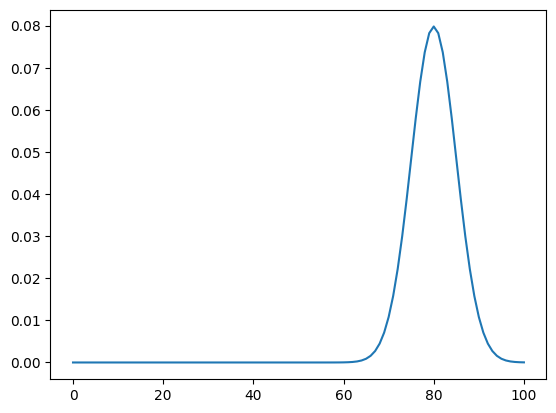

In [88]:
sigma=5

plt.plot([x for x in range(101)],[truncated_gaussian_pdf(x,80,sigma) for x in range(101)])
plt.show()


La valeur de sigma à 5 donne un intervalle plutôt convenable gardons la. On va partir de différents point p et voir.

In [89]:
def truncated_gaussian_cdf_function(p):
    return lambda x : truncated_gaussian_cdf(x,p,sigma)

In [122]:
p=50
pourcentages = grid_search(truncated_gaussian_cdf_function(p))[1]
z_list=[pourcentages]
for i in range(10):
    val,pourcentages = grid_search(truncated_gaussian_cdf_function(pourcentages[2]))
    z_list.append(pourcentages)
print(z_list)
print(val)

[(11, 32, 57), (10, 27, 63), (9, 23, 68), (8, 19, 73), (23, 77, 0), (21, 68, 11), (19, 61, 20), (18, 54, 28), (16, 48, 36), (14, 42, 44), (13, 36, 51)]
190762.04090905175


In [123]:
p=20
pourcentages = grid_search(truncated_gaussian_cdf_function(p))[1]
z_list=[pourcentages]
for i in range(10):
    val,pourcentages = grid_search(truncated_gaussian_cdf_function(pourcentages[2]))
    z_list.append(pourcentages)
print(z_list)
print(val)

[(18, 54, 28), (16, 48, 36), (14, 42, 44), (13, 36, 51), (11, 31, 58), (10, 26, 64), (9, 22, 69), (8, 18, 74), (23, 77, 0), (21, 68, 11), (19, 61, 20)]
432749.0311317341


In [124]:
p=80
pourcentages = grid_search(truncated_gaussian_cdf_function(p))[1]
z_list=[pourcentages]
print(z_list)
pourcentages = (23,77,1) # On avait (23,77,0) j'ai décalé pour évité de diviser par zéro
for i in range(10):
    val,pourcentages = grid_search(truncated_gaussian_cdf_function(pourcentages[2]))
    z_list.append(pourcentages)
print(z_list)
print(val)

[(23, 77, 0)]
[(23, 77, 0), (21, 68, 11), (19, 61, 20), (18, 54, 28), (16, 48, 36), (14, 42, 44), (13, 36, 51), (11, 31, 58), (10, 26, 64), (9, 22, 69), (8, 18, 74)]
42750.02160257344




Pour ce cas-ci on trouve que la valeur optimale z ne fait qu'augmenter jusqu'à recommencer à partir de 25 environs. Il n'y a pas de convergence donc il faudra supposer que les joueurs n'anticiperont que quelque fois et bien guess leur guess initial. 

CINQUIEME RESULTAT:

à chaque nouvelle itération, z augmente de 7 à 10 environ pour une gaussienne

On va prendre la Cauchy tronquée entre 0 et 100 qui est moins pointu 

In [98]:
def truncated_cauchy_pdf(x, p, gamma, a=0, b=100):
    Z = np.arctan((b - p)/gamma) - np.arctan((a - p)/gamma)
    return (1/(np.pi*gamma*(1 + ((x - p)/gamma)**2))) / Z

def truncated_cauchy_cdf(x, p, gamma, a=0, b=100):
    Z = np.arctan((b - p)/gamma) - np.arctan((a - p)/gamma)
    return (np.arctan((x - p)/gamma) - np.arctan((a - p)/gamma)) / Z

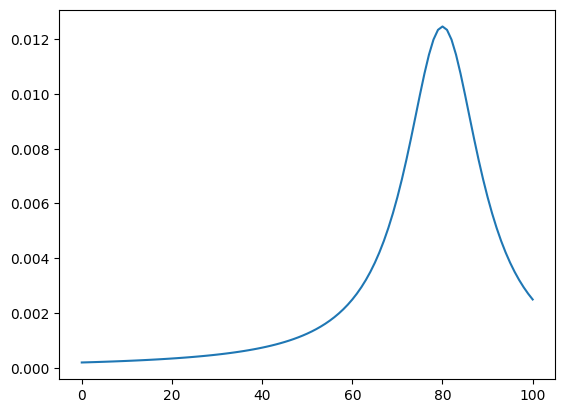

In [115]:
gamma=10
plt.plot([x for x in range(101)],[truncated_cauchy_pdf(x,80,gamma) for x in range(101)])
plt.show()

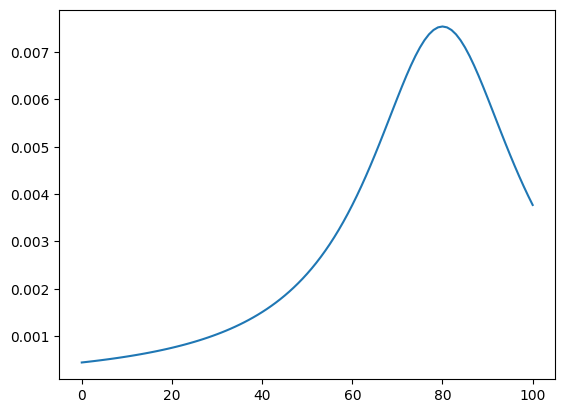

In [118]:
gamma=20
plt.plot([x for x in range(101)],[truncated_cauchy_pdf(x,80,gamma) for x in range(101)])
plt.show()

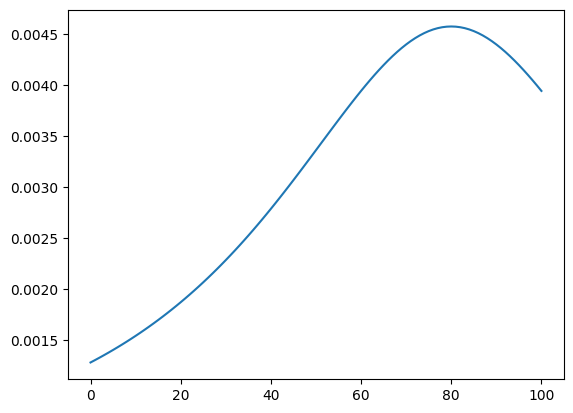

In [103]:
gamma=50
plt.plot([x for x in range(101)],[truncated_cauchy_pdf(x,80,gamma) for x in range(101)])
plt.show()

On va tester pour gamma = 10, 20 et 50

In [113]:
gamma=10
def truncated_cauchy_cdf_function(p):
    return lambda x : truncated_cauchy_cdf(x,p,gamma)

In [125]:
p=10
pourcentages = grid_search(truncated_cauchy_cdf_function(p))[1]
z_list=[pourcentages]
for i in range(10):
    val,pourcentages = grid_search(truncated_cauchy_cdf_function(pourcentages[2]))
    z_list.append(pourcentages)
print(z_list)
print(val)

[(16, 50, 34), (15, 45, 40), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41)]
117803.55441940419


On retrouve pareil que la gaussienne donc trop similaire en terme de pointu avec gamma=10 ?

In [126]:
gamma=20
def truncated_cauchy_cdf_function(p):
    return lambda x : truncated_cauchy_cdf(x,p,gamma)

p=10
pourcentages = grid_search(truncated_cauchy_cdf_function(p))[1]
z_list=[pourcentages]
for i in range(10):
    val,pourcentages = grid_search(truncated_cauchy_cdf_function(pourcentages[2]))
    z_list.append(pourcentages)
print(z_list)
print(val)

[(17, 54, 29), (15, 45, 40), (14, 39, 47), (13, 35, 52), (12, 33, 55), (12, 32, 56), (11, 32, 57), (11, 31, 58), (11, 31, 58), (11, 31, 58), (11, 31, 58)]
71279.24949988631


In [127]:
p=80
pourcentages = grid_search(truncated_cauchy_cdf_function(p))[1]
z_list=[pourcentages]
for i in range(10):
    val,pourcentages = grid_search(truncated_cauchy_cdf_function(pourcentages[2]))
    z_list.append(pourcentages)
print(z_list)
print(val)

[(23, 77, 0), (18, 57, 25), (16, 47, 37), (14, 41, 45), (13, 37, 50), (12, 34, 54), (12, 32, 56), (11, 32, 57), (11, 31, 58), (11, 31, 58), (11, 31, 58)]
71279.24949988631


Pour gamma=20 on retrouve notre converge:

$(x,y,z) = (11, 31, 58)$ dans ce cas si

In [128]:
gamma=50
def truncated_cauchy_cdf_function(p):
    return lambda x : truncated_cauchy_cdf(x,p,gamma)

p=10
pourcentages = grid_search(truncated_cauchy_cdf_function(p))[1]
z_list=[pourcentages]
for i in range(10):
    val,pourcentages = grid_search(truncated_cauchy_cdf_function(pourcentages[2]))
    z_list.append(pourcentages)
print(z_list)
print(val)

p=80
pourcentages = grid_search(truncated_cauchy_cdf_function(p))[1]
z_list=[pourcentages]
for i in range(10):
    val,pourcentages = grid_search(truncated_cauchy_cdf_function(pourcentages[2]))
    z_list.append(pourcentages)
print(z_list)
print(val)

[(16, 50, 34), (15, 45, 40), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41)]
117803.55441940419
[(15, 42, 43), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41), (15, 44, 41)]
117803.55441940419


Là on a convergence vers $(x,y,z) = (15, 44, 41)$

On s'en doutait mais:

SIXIEME RESULTAT:

Il semble que si le pique est plus étalé il y a convergence !!

